### Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg, optimize
import qutip as qu
import sympy as sym

In [2]:
# Set font size of plot elements\n",
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 18
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

### Functions

In [3]:
def gen_Hd(Δ1, Δ2, γ1, γ2, g10, g21):
    """
    function to generate the Hamiltonian corresponding to the |0,0>, |0,1>, and |0,2> states
    """
    return np.array([[0, g10, 0],
                     [g10, -Δ1 -1j*γ1, g21],
                     [0, g21, -Δ1 - Δ2 - 1j*γ2]])

In [4]:
def gen_H0(Δ1, Δ2, δc, κ, γ1, γ2, γ3, g10, g21, g32):
    """
    function to generate the Hamiltonian corresponding to the |1,0>, |1,1>, |1,2>, and |0,3> states
    """
    return np.array([[-1j*κ, g10, 0, 0],
                     [g10, -Δ1 -1j*κ - 1j*γ1, g21, 0],
                     [0, g21, -Δ1 -Δ2 -1j*κ -1j*γ2, g32],
                     [0, 0, g32, -Δ1 -Δ2 -δc -1j*γ3]])
    

### Universal Parameters

In [5]:
# Define the linewidths
κ = 1
γ1 = 1
γ2 = 0.05
γ3 = γ2

# Define the detunings (except for δc)
Δ1 = 0
Δ2 = 0

# Define the range of δc we'll consider
δc = np.linspace(-400, 400, 1000)

### I) $g_{10} \gg g_{21}$, large $g_{32}$

In [6]:
# Define our parameters
g10 = 50
g21 = 10
g32 = 50

In [7]:
# Get the 'dark state' Hamiltonian
Hd_1 = gen_Hd(Δ1, Δ2, γ1, γ2, g10, g21)

# Get the 4 level hamiltonian for each detuning value and store the eigenvalues
H0_1s = np.zeros((δc.shape[0], 4, 4), dtype=complex)
λ_1s = np.zeros((δc.shape[0], 4), dtype=complex)
for i in range(δc.shape[0]):
    H0_1s[i] = gen_H0(Δ1, Δ2, δc[i], κ, γ1, γ2, γ3, g10, g21, g32)
    λ_1s[i] = np.sort(linalg.eigvals(H0_1s[i]))

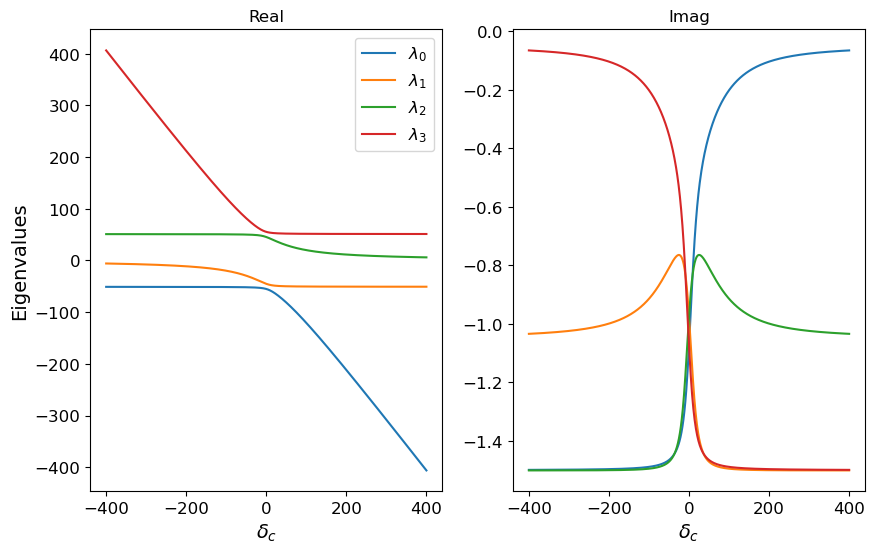

In [8]:
fig = plt.figure(1, figsize=(10, 6))
ax = fig.subplots(1, 2)
for i in range(4):
    ax[0].plot(δc, λ_1s.T[i].real, label='$\\lambda_'+str(i)+'$')
    ax[1].plot(δc, λ_1s.T[i].imag)
ax[0].set_xlabel("$\\delta_c$")
ax[1].set_xlabel("$\\delta_c$")
ax[0].set_ylabel("Eigenvalues")
ax[0].set_title("Real")
ax[1].set_title("Imag")
ax[0].legend()

### II) $g_{10} \gg g_{21}$, small $g_{32}$

In [9]:
# Define our parameters
g10 = 50
g21 = 10
g32 = 10

In [10]:
# Get the 'dark state' Hamiltonian
Hd_2 = gen_Hd(Δ1, Δ2, γ1, γ2, g10, g21)

# Get the 4 level hamiltonian for each detuning value and store the eigenvalues
H0_2s = np.zeros((δc.shape[0], 4, 4), dtype=complex)
λ_2s = np.zeros((δc.shape[0], 4), dtype=complex)
for i in range(δc.shape[0]):
    H0_2s[i] = gen_H0(Δ1, Δ2, δc[i], κ, γ1, γ2, γ3, g10, g21, g32)
    λ_2s[i] = np.sort(linalg.eigvals(H0_2s[i]))

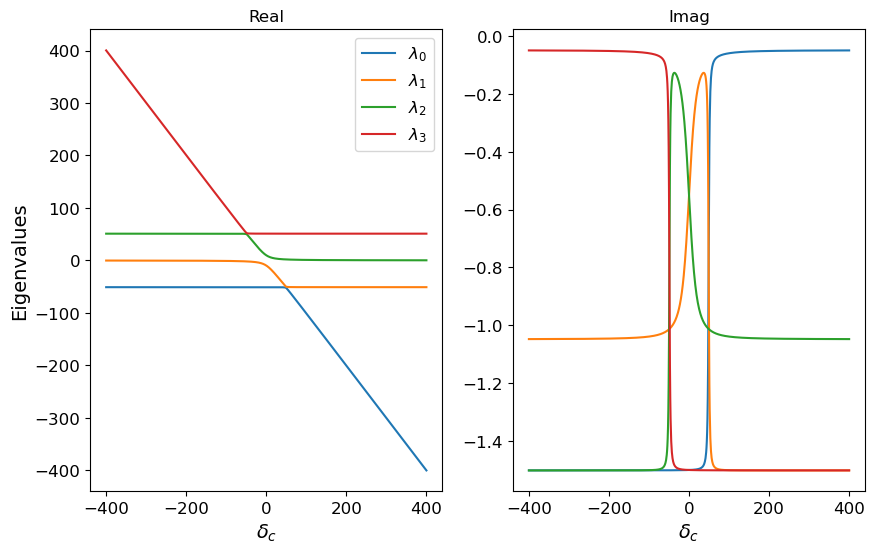

In [11]:
fig = plt.figure(1, figsize=(10, 6))
ax = fig.subplots(1, 2)
for i in range(4):
    ax[0].plot(δc, λ_2s.T[i].real, label='$\\lambda_'+str(i)+'$')
    ax[1].plot(δc, λ_2s.T[i].imag)
ax[0].set_xlabel("$\\delta_c$")
ax[1].set_xlabel("$\\delta_c$")
ax[0].set_ylabel("Eigenvalues")
ax[0].set_title("Real")
ax[1].set_title("Imag")
ax[0].legend()

### III) $g_{10} = g_{21}$, large $g_{32}$

In [12]:
# Define our parameters
g10 = 10
g21 = 10
g32 = 50

In [13]:
# Get the 'dark state' Hamiltonian
Hd_3 = gen_Hd(Δ1, Δ2, γ1, γ2, g10, g21)

# Get the 4 level hamiltonian for each detuning value and store the eigenvalues
H0_3s = np.zeros((δc.shape[0], 4, 4), dtype=complex)
λ_3s = np.zeros((δc.shape[0], 4), dtype=complex)
for i in range(δc.shape[0]):
    H0_3s[i] = gen_H0(Δ1, Δ2, δc[i], κ, γ1, γ2, γ3, g10, g21, g32)
    λ_3s[i] = np.sort(linalg.eigvals(H0_3s[i]))

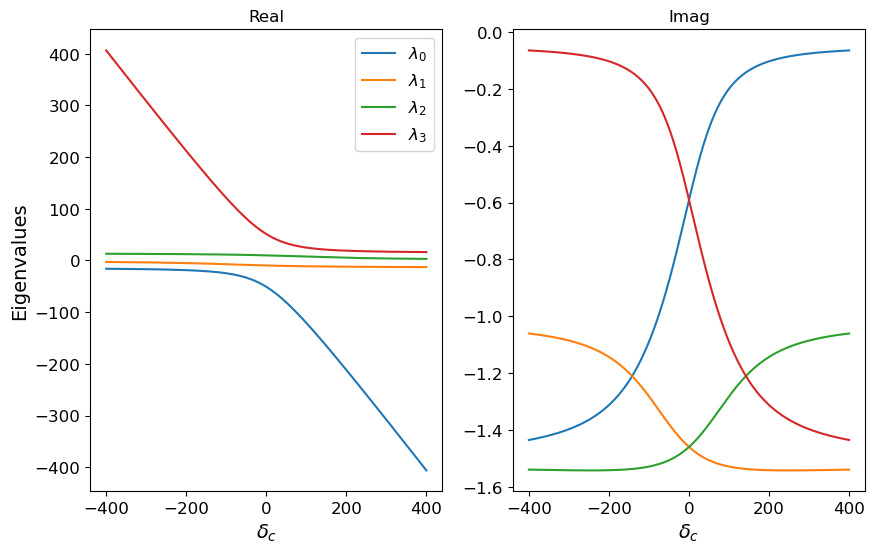

In [14]:
fig = plt.figure(1, figsize=(10, 6))
ax = fig.subplots(1, 2)
for i in range(4):
    ax[0].plot(δc, λ_3s.T[i].real, label='$\\lambda_'+str(i)+'$')
    ax[1].plot(δc, λ_3s.T[i].imag)
ax[0].set_xlabel("$\\delta_c$")
ax[1].set_xlabel("$\\delta_c$")
ax[0].set_ylabel("Eigenvalues")
ax[0].set_title("Real")
ax[1].set_title("Imag")
ax[0].legend()

### IV) $g_{10} = g_{21}$, small $g_{32}$

In [15]:
# Define our parameters
g10 = 50
g21 = 50
g32 = 10

In [16]:
# Get the 'dark state' Hamiltonian
Hd_4 = gen_Hd(Δ1, Δ2, γ1, γ2, g10, g21)

# Get the 4 level hamiltonian for each detuning value and store the eigenvalues
H0_4s = np.zeros((δc.shape[0], 4, 4), dtype=complex)
λ_4s = np.zeros((δc.shape[0], 4), dtype=complex)
for i in range(δc.shape[0]):
    H0_4s[i] = gen_H0(Δ1, Δ2, δc[i], κ, γ1, γ2, γ3, g10, g21, g32)
    λ_4s[i] = np.sort(linalg.eigvals(H0_4s[i]))

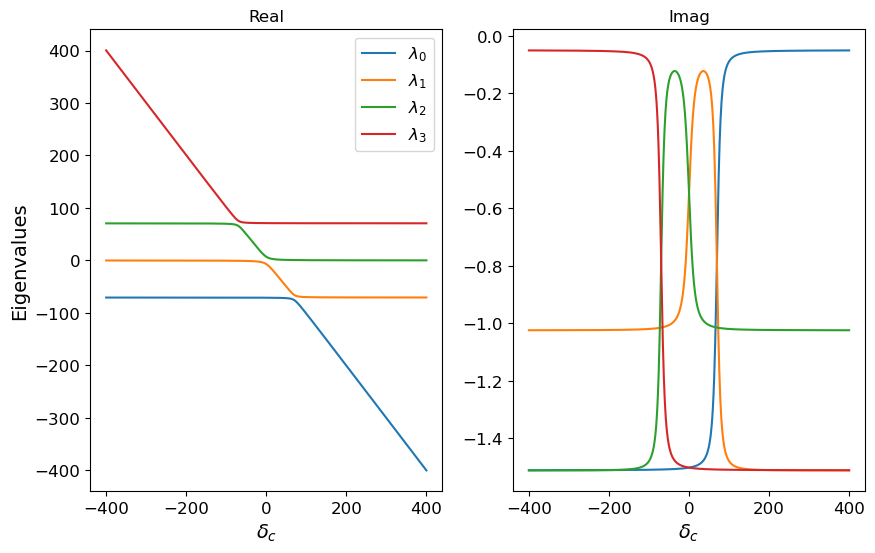

In [17]:
fig = plt.figure(1, figsize=(10, 6))
ax = fig.subplots(1, 2)
for i in range(4):
    ax[0].plot(δc, λ_4s.T[i].real, label='$\\lambda_'+str(i)+'$')
    ax[1].plot(δc, λ_4s.T[i].imag)
ax[0].set_xlabel("$\\delta_c$")
ax[1].set_xlabel("$\\delta_c$")
ax[0].set_ylabel("Eigenvalues")
ax[0].set_title("Real")
ax[1].set_title("Imag")
ax[0].legend()

### V) $g_{10} \ll g_{21}$, large $g_{32}$

In [18]:
# Define our parameters
g10 = 10
g21 = 50
g32 = 50

In [19]:
# Get the 'dark state' Hamiltonian
Hd_5 = gen_Hd(Δ1, Δ2, γ1, γ2, g10, g21)

# Get the 4 level hamiltonian for each detuning value and store the eigenvalues
H0_5s = np.zeros((δc.shape[0], 4, 4), dtype=complex)
λ_5s = np.zeros((δc.shape[0], 4), dtype=complex)
for i in range(δc.shape[0]):
    H0_5s[i] = gen_H0(Δ1, Δ2, δc[i], κ, γ1, γ2, γ3, g10, g21, g32)
    λ_5s[i] = np.sort(linalg.eigvals(H0_5s[i]))

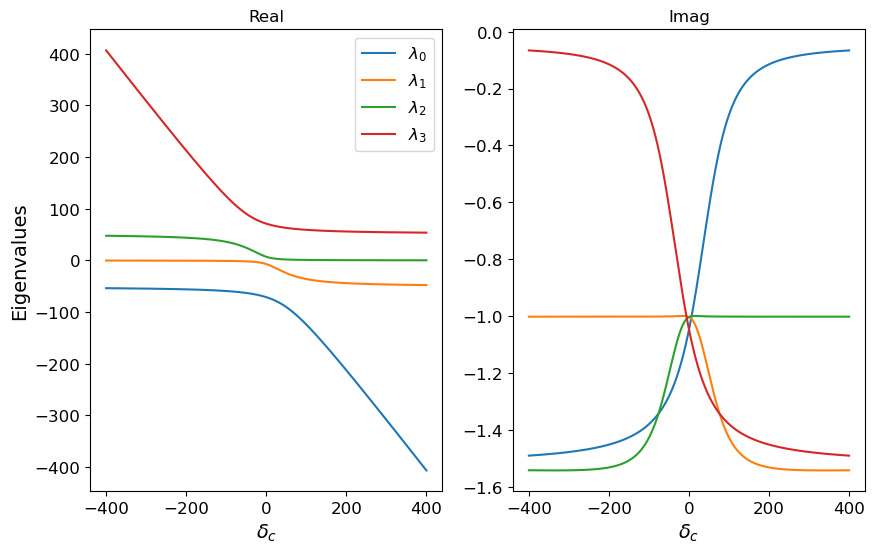

In [20]:
fig = plt.figure(1, figsize=(10, 6))
ax = fig.subplots(1, 2)
for i in range(4):
    ax[0].plot(δc, λ_5s.T[i].real, label='$\\lambda_'+str(i)+'$')
    ax[1].plot(δc, λ_5s.T[i].imag)
ax[0].set_xlabel("$\\delta_c$")
ax[1].set_xlabel("$\\delta_c$")
ax[0].set_ylabel("Eigenvalues")
ax[0].set_title("Real")
ax[1].set_title("Imag")
ax[0].legend()

### VI) $g_{10} \ll g_{21}$, small $g_{32}$

In [21]:
# Define our parameters
g10 = 10
g21 = 50
g32 = 10

In [22]:
# Get the 'dark state' Hamiltonian
Hd_6 = gen_Hd(Δ1, Δ2, γ1, γ2, g10, g21)

# Get the 4 level hamiltonian for each detuning value and store the eigenvalues
H0_6s = np.zeros((δc.shape[0], 4, 4), dtype=complex)
λ_6s = np.zeros((δc.shape[0], 4), dtype=complex)
for i in range(δc.shape[0]):
    H0_6s[i] = gen_H0(Δ1, Δ2, δc[i], κ, γ1, γ2, γ3, g10, g21, g32)
    λ_6s[i] = np.sort(linalg.eigvals(H0_6s[i]))

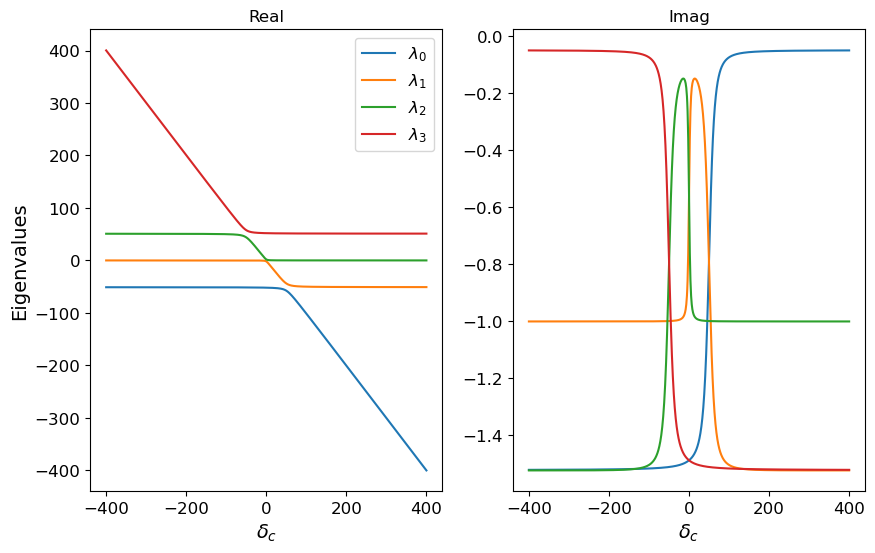

In [23]:
fig = plt.figure(1, figsize=(10, 6))
ax = fig.subplots(1, 2)
for i in range(4):
    ax[0].plot(δc, λ_6s.T[i].real, label='$\\lambda_'+str(i)+'$')
    ax[1].plot(δc, λ_6s.T[i].imag)
ax[0].set_xlabel("$\\delta_c$")
ax[1].set_xlabel("$\\delta_c$")
ax[0].set_ylabel("Eigenvalues")
ax[0].set_title("Real")
ax[1].set_title("Imag")
ax[0].legend()